# Исследовательский анализ данных

Цель этого ноутбука — исследовать связь признаков, доступных в момент оформления заказа, с задержкой доставки и сформировать обоснованные наборы признаков для моделирования.

Сначала рассматриваются исходные характеристики заказа, покупателя, товаров и продавцов. Затем отдельно анализируются дополнительные признаки: расстояние доставки, основной штат продавца, основная категория товара и совпадение штатов покупателя и продавца.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('../data/processed/dataset.csv', parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                                                                         'order_delivered_customer_date', 'order_estimated_delivery_date'])

In [3]:
dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delayed,customer_unique_id,...,max_volume,seller_states,max_delivery_distance_km,main_seller_state,main_product_category,same_state_delivery,order_purchase_month,order_purchase_dayofweek,order_purchase_hour,estimated_delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,7c396fd4830fd04220f754e42b4e5bff,...,1976.0,1,18.681711,SP,utilidades_domesticas,1.0,10,0,10,15.544063
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,af07308b275d755c9edb36a90c618231,...,4693.0,1,861.035367,SP,perfumaria,0.0,7,1,20,19.137766
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,3a653a41f6f9fc3d2a113cf8398680e8,...,9576.0,1,514.547140,SP,automotivo,0.0,8,2,8,26.639711
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,7c142cf63193a1473d2e66489a9ae977,...,6000.0,1,1821.802656,MG,pet_shop,0.0,11,5,19,26.188819
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,72632f0f9dd73dfee390c9b22eb56dd6,...,11475.0,1,29.593095,SP,papelaria,1.0,2,1,21,12.112049


In [4]:
dataset.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
is_delayed                                 bool
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
customer_lat                            float64
customer_lng                            float64
items                                     int64
products                                  int64
sellers                                   int64
total_price                             float64
total_freight_value                     float64
categories                              

In [5]:
dataset.shape

(96470, 36)

In [6]:
dataset['is_delayed'].value_counts()

is_delayed
False    89936
True      6534
Name: count, dtype: int64

In [7]:
dataset['is_delayed'].value_counts(normalize=True)

is_delayed
False    0.932269
True     0.067731
Name: proportion, dtype: float64

Задержанными оказались 6,8% доставленных заказов (6 534 из 96 470). Целевой класс несбалансирован: при моделировании нельзя ориентироваться только на accuracy, поскольку модель, всегда предсказывающая своевременную доставку, уже будет давать высокую формальную точность.

## Временные закономерности

Проверим, связана ли доля задержек с месяцем, днём недели и временем оформления заказа.

In [8]:
def plot_delay_rate_by(col, x_label, title):
    delay_by_col = (
        dataset.groupby(col)['is_delayed']
        .mean()
        .reset_index()
    )

    sns.barplot(data=delay_by_col, x=col, y='is_delayed')
    plt.xlabel(x_label)
    plt.ylabel('Доля задержанных заказов')
    plt.title(title)
    plt.show()

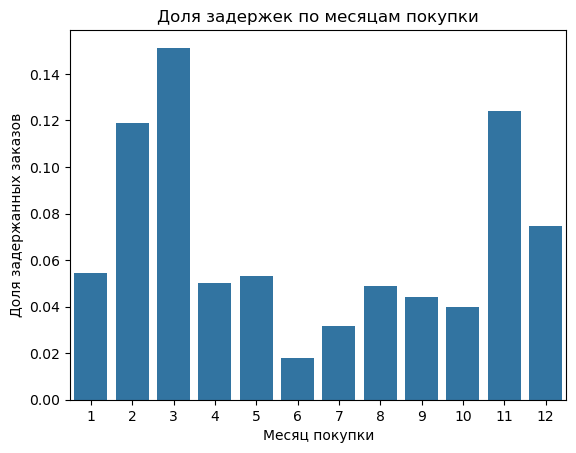

In [9]:
plot_delay_rate_by(
    'order_purchase_month',
    'Месяц покупки',
    'Доля задержек по месяцам покупки'
)

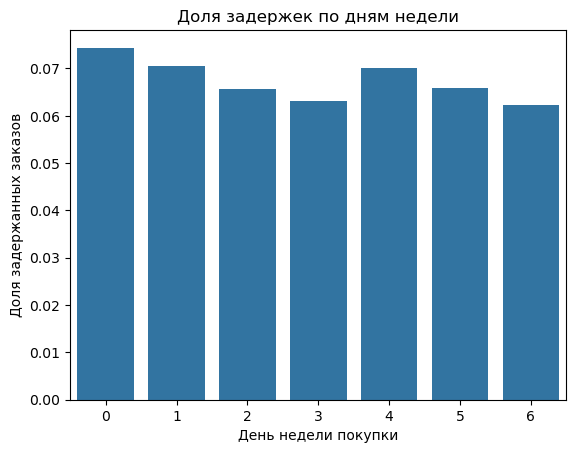

In [10]:
plot_delay_rate_by(
    'order_purchase_dayofweek',
    'День недели покупки',
    'Доля задержек по дням недели'
)

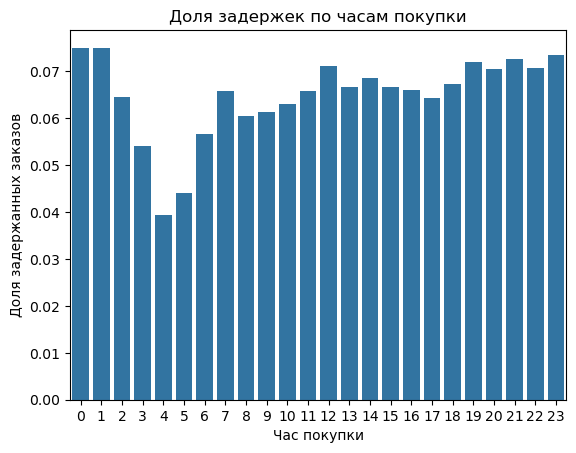

In [11]:
plot_delay_rate_by(
    'order_purchase_hour',
    'Час покупки',
    'Доля задержек по часам покупки'
)

Доля задержек заметно меняется в зависимости от месяца покупки: максимальные значения наблюдаются в марте и ноябре, а минимальное — в июне. Это указывает на возможную сезонность, поэтому месяц покупки стоит сохранить для базовой модели.

По дням недели различия невелики: доля задержек находится примерно в диапазоне 6,2–7,4%. Час покупки также связан с задержками слабо: наиболее низкая доля наблюдается у заказов, оформленных ранним утром, однако для большинства часов значения близки. Оба признака пока оставляем для модели и проверим их вклад уже по её результатам.

## Обещанный срок доставки

Проверим, как обещанный срок доставки связан с долей задержанных заказов. Нас интересует, увеличивается ли риск задержки при слишком коротком или, наоборот, слишком длительном сроке.

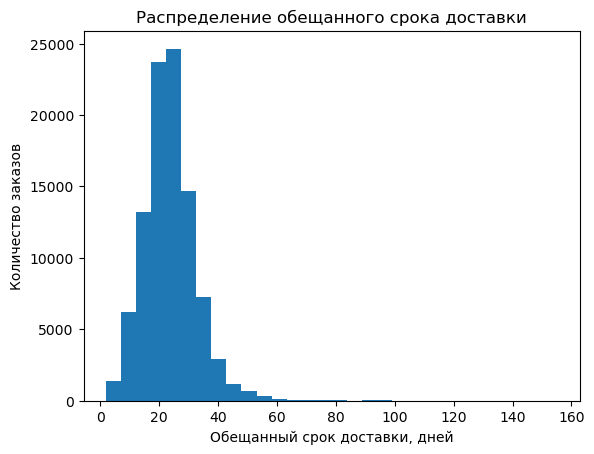

In [12]:
plt.hist(data=dataset, x='estimated_delivery_days', bins=30)
plt.xlabel('Обещанный срок доставки, дней')
plt.ylabel('Количество заказов')
plt.title('Распределение обещанного срока доставки')
plt.show()

In [13]:
dataset['estimated_days_groups'] = pd.cut(
    dataset['estimated_delivery_days'],
    bins=[0, 3, 7, 14, 21, 30, np.inf],
    labels=['0-3', '3-7', '7-14', '14-21', '21-30', '30+'],
    include_lowest=True
)


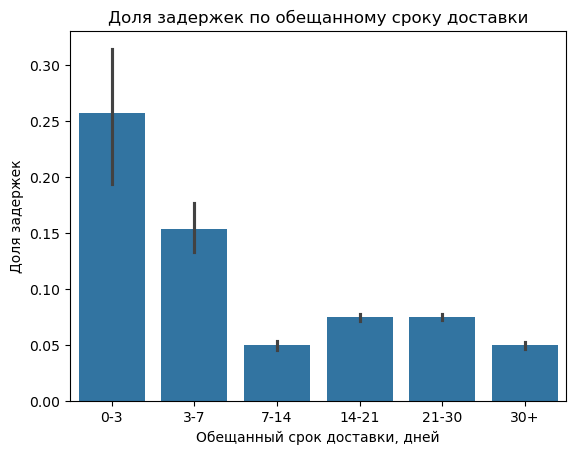

In [14]:
sns.barplot(data=dataset, x='estimated_days_groups', y='is_delayed')
plt.title('Доля задержек по обещанному сроку доставки')
plt.xlabel('Обещанный срок доставки, дней')
plt.ylabel('Доля задержек')
plt.show()

In [15]:
dataset.groupby('estimated_days_groups', observed=True).agg(
    delay_rate=('is_delayed', 'mean'),
    orders=('order_id', 'size')
)

,delay_rate,orders
estimated_days_groups,,
0-3,0.256545,191
3-7,0.153414,1069
7-14,0.049525,10742
14-21,0.074236,23304
21-30,0.074445,41292
30+,0.049567,19872


Заказы с коротким обещанным сроком доставки задерживаются заметно чаще: для сроков до 3 дней доля задержек составляет 25,7%, а для сроков от 3 до 7 дней — 15,3%. Однако первая группа включает только 191 заказ, поэтому её результат менее устойчив.

Для сроков от 7 дней доля задержек находится примерно в диапазоне 5–7,4%. Длительный обещанный срок сам по себе не связан с повышенным риском задержки: в группе 30+ дней доля задержек составляет около 5%.

Признак `estimated_delivery_days` содержит выраженный сигнал и должен быть включён в базовую модель. Созданные интервалы также можно рассмотреть как дополнительный категориальный признак.

## Логистическая сложность заказа

Проверим, связана ли доля задержек с количеством продавцов и штатов продавцов в заказе. Заказ с товарами от нескольких продавцов, особенно из разных штатов, может требовать более сложной координации поставок и поэтому иметь повышенный риск задержки.

In [16]:
dataset['sellers'].value_counts().sort_index()

sellers
1    95195
2     1216
3       54
4        3
5        2
Name: count, dtype: int64

In [17]:
dataset['seller_states'].value_counts().sort_index()

seller_states
1    95961
2      502
3        7
Name: count, dtype: int64

In [18]:
dataset.groupby('sellers').agg(
    delay_rate=('is_delayed', 'mean'),
    orders=('order_id', 'size')
)

,delay_rate,orders
sellers,,
1,0.068501,95195
2,0.010691,1216
3,0.000000,54
4,0.000000,3
5,0.000000,2


In [19]:
dataset.groupby('seller_states').agg(
    delay_rate=('is_delayed', 'mean'),
    orders=('order_id', 'size')
)

,delay_rate,orders
seller_states,,
1,0.068059,95961
2,0.005976,502
3,0.000000,7


Предположение о повышенном риске задержки для логистически сложных заказов не подтвердилось. Напротив, заказы с двумя продавцами задерживались реже заказов с одним продавцом: 1,1% против 6,9%. Аналогичная зависимость наблюдается для географии продавцов: при наличии продавцов из двух штатов доля задержек составила 0,6% против 6,8% для одного штата.

Результаты для заказов с тремя и более продавцами или штатами нельзя считать устойчивыми из-за малого количества наблюдений. Обнаруженная зависимость также не означает, что увеличение числа продавцов само по себе снижает риск задержки: она может объясняться другими особенностями таких заказов, например более длительным обещанным сроком доставки.

Признаки `sellers` и `seller_states` пока следует сохранить: они связаны с целевой переменной, хотя направление связи оказалось противоположным первоначальной гипотезе.

In [20]:
dataset['weight_group'] = pd.qcut(
    dataset['total_weight'],
    q=5,
    duplicates='drop'
)

In [21]:
dataset.groupby('weight_group', observed=True).agg(
    delay_rate=('is_delayed', 'mean'),
    orders=('order_id', 'size'),
    median_weight=('total_weight', 'median')
)

,delay_rate,orders,median_weight
weight_group,,,
"(1.999, 250.0]",0.060853,20492,183.0
"(250.0, 500.0]",0.070209,18331,375.0
"(500.0, 1100.0]",0.062451,19055,750.0
"(1100.0, 2800.0]",0.070292,19419,1650.0
"(2800.0, 184400.0]",0.075453,19151,6600.0


In [22]:
dataset['volume_group'] = pd.qcut(
    dataset['total_volume'],
    q=5,
    duplicates='drop'
)

In [23]:
dataset.groupby('volume_group', observed=True).agg(
    delay_rate=('is_delayed', 'mean'),
    orders=('order_id', 'size'),
    median_volume=('total_volume', 'median')
)

,delay_rate,orders,median_volume
volume_group,,,
"(167.999, 2520.0]",0.062400,19471,1425.0
"(2520.0, 4800.0]",0.072426,19123,3570.0
"(4800.0, 10260.0]",0.061159,19294,7260.0
"(10260.0, 24288.0]",0.070650,19278,15939.0
"(24288.0, 1476000.0]",0.072169,19288,42978.0


In [24]:
dataset['max_volume'].corr(dataset['total_volume'])

0.8780025267115301

Явной монотонной зависимости задержек от физических характеристик заказа не обнаружено. В группах веса и объёма доля задержек колеблется примерно от 6,1% до 7,5%, но не увеличивается последовательно с ростом этих признаков. В наиболее тяжёлых и объёмных группах доля задержек немного выше, однако различия невелики.

`max_volume` сильно коррелирует с `total_volume` (коэффициент корреляции — 0,88), поэтому отдельно анализировать его связь с задержками не стали. `total_weight` и `total_volume` пока сохраним для проверки в модели, а необходимость использования `max_volume` определим на этапе отбора признаков.


In [25]:
dataset[['items', 'products', 'categories']].describe()

,items,products,categories
count,96470.000000,96470.000000,96470.000000
mean,1.142210,1.038540,0.993843
std,0.538824,0.227951,0.147413
min,1.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,21.000000,8.000000,3.000000


In [26]:
dataset.groupby('items').agg(
    delay_rate=('is_delayed', 'mean'),
    orders=('order_id', 'size')).head(10)

,delay_rate,orders
items,,
1,0.069373,86835
2,0.053707,7392
3,0.049005,1306
4,0.046465,495
5,0.046632,193
6,0.083770,191
7,0.000000,22
8,0.000000,8
9,0.000000,3


In [27]:
dataset.groupby('products').agg(
    delay_rate=('is_delayed', 'mean'),
    orders=('order_id', 'size'))

,delay_rate,orders
products,,
1,0.068744,93273
2,0.040598,2808
3,0.023490,298
4,0.014493,69
5,0.000000,8
6,0.000000,10
7,0.000000,3
8,0.000000,1


In [28]:
dataset.groupby('categories').agg(
    delay_rate=('is_delayed', 'mean'),
    orders=('order_id', 'size'))

,delay_rate,orders
categories,,
0,0.071321,1332
1,0.068082,94415
2,0.015537,708
3,0.000000,15


Предположение о повышенном риске задержки для более крупных и разнообразных заказов не подтвердилось. Заказы с одной позицией задерживались в 6,9% случаев, тогда как для заказов с двумя–пятью позициями доля задержек составляла примерно 4,6–5,4%. Аналогичная обратная зависимость наблюдается для количества уникальных товаров и категорий.

Результаты для заказов с большим количеством позиций, товаров или категорий нельзя считать устойчивыми из-за малого числа наблюдений. Значение `categories = 0` соответствует отсутствию сведений о категории и не характеризует размер заказа.

Обнаруженная связь не означает, что увеличение размера заказа само по себе снижает риск задержки: различия могут объясняться другими особенностями таких заказов. Признаки `items`, `products` и `categories` пока сохраним для проверки в модели.


In [29]:
dataset['price_group'] = pd.qcut(
    dataset['total_price'],
    q=10,
    duplicates='drop'
)

In [30]:
dataset.groupby('price_group', observed=True)['is_delayed'].mean()

price_group
(0.849, 25.0]       0.058132
(25.0, 39.0]        0.059692
(39.0, 50.0]        0.062969
(50.0, 67.9]        0.068224
(67.9, 86.5]        0.066514
(86.5, 106.6]       0.065519
(106.6, 132.9]      0.069469
(132.9, 175.0]      0.077186
(175.0, 269.0]      0.069700
(269.0, 13440.0]    0.080050
Name: is_delayed, dtype: float64

In [31]:
dataset['freight_value_group'] = pd.qcut(
    dataset['total_freight_value'],
    q=10,
    duplicates='drop'
)

In [32]:
dataset.groupby('freight_value_group', observed=True)['is_delayed'].mean()

freight_value_group
(-0.001, 9.34]       0.042424
(9.34, 12.83]        0.045997
(12.83, 14.53]       0.052549
(14.53, 15.64]       0.068295
(15.64, 17.17]       0.075816
(17.17, 18.59]       0.076298
(18.59, 21.96]       0.078524
(21.96, 27.38]       0.075148
(27.38, 39.381]      0.077578
(39.381, 1794.96]    0.084897
Name: is_delayed, dtype: float64

## Стоимость заказа и доставки

С увеличением стоимости заказа наблюдается слабая положительная связь с задержками: в самом дешёвом дециле доля задержанных заказов составляет 5,8%, а в самом дорогом — 8,0%. При этом рост не является строго монотонным, поэтому стоимость товаров сама по себе не выглядит сильным фактором задержки.

Связь со стоимостью доставки выражена заметнее. В группе с минимальной стоимостью доставки доля задержек составляет 4,2%, а в группе с максимальной — 8,5%. После стоимости доставки около 15–17 единиц показатель в основном находится на уровне 7,5–8,5%.

Высокая стоимость доставки может отражать особенности логистики заказа, например расстояние, вес, объём или сложность маршрута. Поэтому `total_price` и `total_freight_value` сохраняются для проверки в базовой модели, однако обнаруженные зависимости не следует интерпретировать как причинные.


## Дополнительные признаки

Для расширения исходного набора были созданы признаки, описывающие расстояние доставки, географию продавца и основную категорию товара.

Проверим распределение этих признаков и их связь с долей задержанных заказов. Для расстояния используются группы одинаковой численности, а для штатов и категорий рассматриваются наиболее распространённые значения, чтобы выводы не основывались на единичных заказах.


,distance_group,delay_rate,orders,median_distance_km
0,"(-0.001, 117.518]",0.045627,19199,34.871541
1,"(117.518, 348.648]",0.058131,19198,278.867803
2,"(348.648, 531.284]",0.065889,19199,435.528467
3,"(531.284, 877.313]",0.071830,19198,696.764096
4,"(877.313, 3398.486]",0.096515,19199,1457.374365


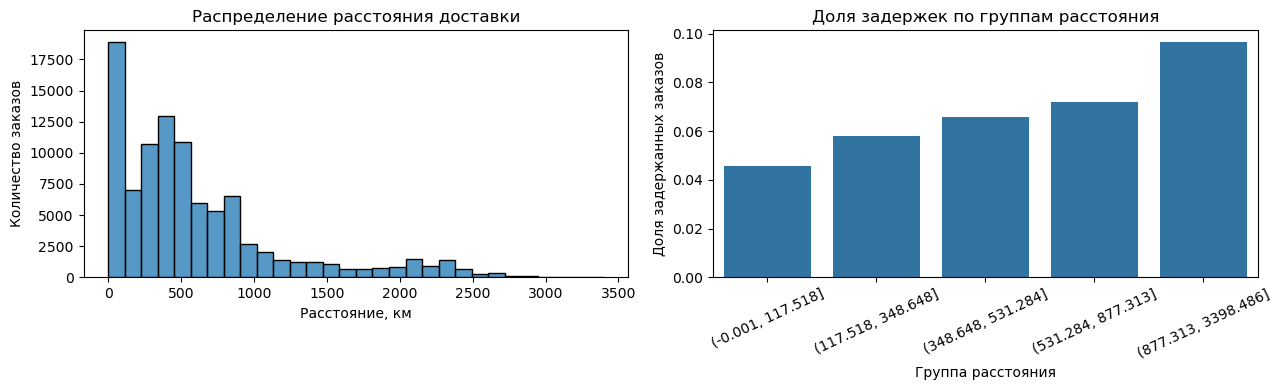

In [33]:
dataset['distance_group'] = pd.qcut(
    dataset['max_delivery_distance_km'],
    q=5,
    duplicates='drop'
)

distance_summary = (
    dataset
    .groupby(
        'distance_group',
        observed=True
    )
    .agg(
        delay_rate=('is_delayed', 'mean'),
        orders=('order_id', 'size'),
        median_distance_km=(
            'max_delivery_distance_km',
            'median'
        )
    )
    .reset_index()
)

display(distance_summary)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

sns.histplot(
    data=dataset,
    x='max_delivery_distance_km',
    bins=30,
    ax=axes[0]
)

axes[0].set_title(
    'Распределение расстояния доставки'
)
axes[0].set_xlabel('Расстояние, км')
axes[0].set_ylabel('Количество заказов')

sns.barplot(
    data=distance_summary,
    x='distance_group',
    y='delay_rate',
    errorbar=None,
    ax=axes[1]
)

axes[1].set_title(
    'Доля задержек по группам расстояния'
)
axes[1].set_xlabel('Группа расстояния')
axes[1].set_ylabel('Доля задержанных заказов')
axes[1].tick_params(
    axis='x',
    rotation=25
)

plt.tight_layout()
plt.show()

In [35]:
same_state_summary = (
    dataset
    .dropna(subset=['same_state_delivery'])
    .groupby(
        'same_state_delivery',
        as_index=False
    )
    .agg(
        delay_rate=('is_delayed', 'mean'),
        orders=('order_id', 'size')
    )
)

same_state_summary['delivery_type'] = (
    same_state_summary['same_state_delivery']
    .map({
        0.0: 'Разные штаты',
        1.0: 'Один штат'
    })
)

same_state_summary

,same_state_delivery,delay_rate,orders,delivery_type
0,0.0,0.080397,61818,Разные штаты
1,1.0,0.045134,34652,Один штат


,main_seller_state,delay_rate,orders
18,RS,0.031282,1950
7,MG,0.048157,7704
19,SC,0.049033,3569
1,BA,0.049091,550
3,DF,0.053284,807
14,PR,0.053772,7476
15,RJ,0.071633,4202
21,SP,0.073439,68261


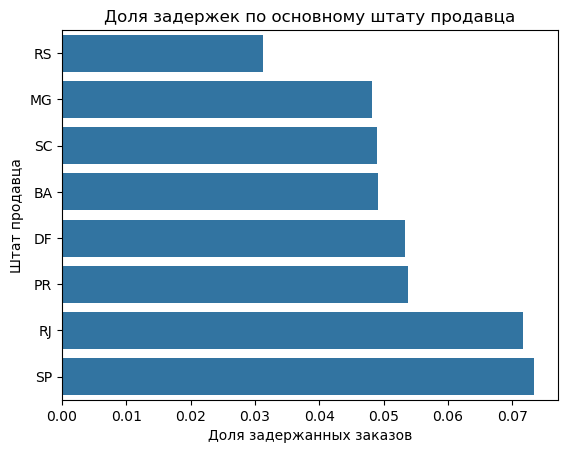

In [36]:
seller_state_summary = (
    dataset
    .groupby(
        'main_seller_state',
        as_index=False
    )
    .agg(
        delay_rate=('is_delayed', 'mean'),
        orders=('order_id', 'size')
    )
)

seller_state_plot_data = (
    seller_state_summary
    .query('orders >= 500')
    .sort_values('delay_rate')
)

display(seller_state_plot_data)

sns.barplot(
    data=seller_state_plot_data,
    x='delay_rate',
    y='main_seller_state',
    errorbar=None
)

plt.title(
    'Доля задержек по основному штату продавца'
)
plt.xlabel('Доля задержанных заказов')
plt.ylabel('Штат продавца')
plt.show()

,main_product_category,delay_rate,orders
72,utilidades_domesticas,0.054317,5652
26,cool_stuff,0.059192,3514
12,brinquedos,0.063970,3783
44,informatica_acessorios,0.064154,6500
40,ferramentas_jardim,0.065828,3418
62,perfumaria,0.065862,3067
32,esporte_lazer,0.065937,7492
70,telefonia,0.071516,4069
54,moveis_decoracao,0.072145,6182
8,automotivo,0.073100,3803


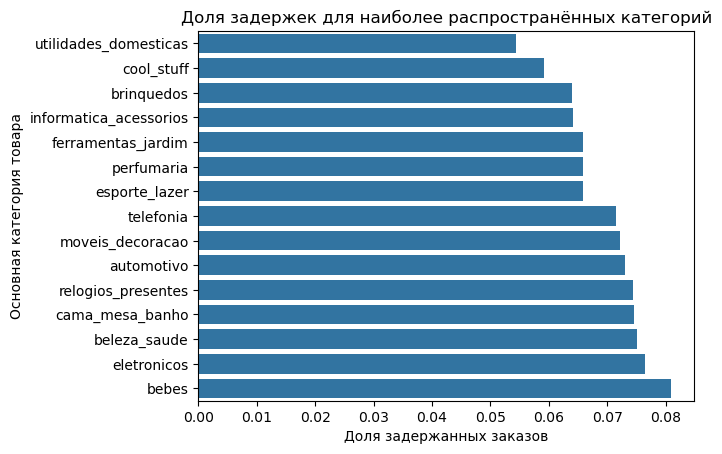

In [37]:
category_summary = (
    dataset
    .groupby(
        'main_product_category',
        as_index=False
    )
    .agg(
        delay_rate=('is_delayed', 'mean'),
        orders=('order_id', 'size')
    )
)

category_plot_data = (
    category_summary
    .nlargest(
        15,
        'orders'
    )
    .sort_values('delay_rate')
)

display(category_plot_data)

sns.barplot(
    data=category_plot_data,
    x='delay_rate',
    y='main_product_category',
    errorbar=None
)

plt.title(
    'Доля задержек для наиболее распространённых категорий'
)
plt.xlabel('Доля задержанных заказов')
plt.ylabel('Основная категория товара')
plt.show()

Расстояние доставки показывает выраженную и почти монотонную связь с целевой переменной. В ближайшей группе задерживается около 4,6% заказов, тогда как в наиболее удалённой — 9,7%. Медианное расстояние в этих группах составляет примерно 35 и 1 457 км соответственно. Поэтому `max_delivery_distance_km` следует проверить в расширенной версии модели.

Для заказов между разными штатами доля задержек составляет 8,0%, а для заказов внутри одного штата — 4,5%. Однако `same_state_delivery` тесно связан с расстоянием и конкретными штатами покупателя и продавца, поэтому эту зависимость нельзя интерпретировать как самостоятельный причинный эффект.

Среди распространённых штатов продавцов доля задержек различается от 3,1% для `RS` до 7,3% для `SP`. При этом большинство заказов относится к продавцам из `SP`, поэтому модель должна учитывать не только долю задержек, но и различия в количестве наблюдений.

Для 15 наиболее распространённых категорий доля задержек находится примерно в диапазоне от 5,4% до 8,1%. Различия присутствуют, но выражены слабее, чем для расстояния и совпадения штатов.

Все четыре дополнительных признака связаны с целевой переменной, однако часть их информации может дублироваться. Поэтому их итоговая полезность будет проверяться путём сравнения исходного и расширенного наборов признаков на временной кросс-валидации.


## Итоги EDA

В датасете содержится 96 470 доставленных заказов, из которых 6,8% были доставлены позже обещанной календарной даты. Целевой класс несбалансирован, поэтому при оценке моделей недостаточно использовать accuracy. Основной метрикой следует выбрать PR-AUC, дополнительно контролируя ROC-AUC.

Наиболее выраженная связь с задержкой среди исходных признаков обнаружена у обещанного срока доставки: заказы с коротким обещанным сроком задерживаются заметно чаще. Доля задержек также в целом повышается с ростом стоимости доставки. Вес, объём, размер и логистическая сложность заказа не показали сильной самостоятельной и последовательной зависимости, но могут быть полезны в сочетании с другими признаками.

Среди дополнительных признаков наиболее выраженная зависимость обнаружена у расстояния доставки: доля задержек увеличивается примерно с 4,6% в ближайшей группе до 9,7% в наиболее удалённой. Заказы между разными штатами также задерживаются чаще заказов внутри одного штата. Основной штат продавца и основная категория товара показывают различия в доле задержек между группами, хотя эти зависимости могут частично объясняться расстоянием, составом заказов и количеством наблюдений.

Для базовой модели используются признаки, доступные в момент оформления заказа: обещанный срок доставки, месяц, день недели и час покупки, штат покупателя, характеристики состава заказа, количество продавцов и их штатов, стоимость товаров и доставки, вес и объём.

В расширенный набор дополнительно включаются максимальное расстояние доставки, основной штат продавца, основная категория товара и признак совпадения штатов покупателя и продавца. Полезность расширенного набора будет оцениваться не по отдельным различиям в EDA, а по изменению качества модели на временной кросс-валидации.

Из набора признаков исключаются идентификаторы (`order_id`, `customer_id`, `customer_unique_id`), а также поля, которые становятся известны после оформления заказа: `order_status`, `order_approved_at`, `order_delivered_carrier_date` и `order_delivered_customer_date`. Исходные временные метки покупки и обещанной доставки не передаются модели напрямую: вместо них используются созданные числовые признаки.

Интервальные колонки, созданные через `cut` и `qcut`, используются только для EDA и не включаются в модель, поскольку дублируют исходные числовые признаки. `customer_city`, ZIP-префикс, `max_volume` и характеристики карточек товаров также исключаются, чтобы не усложнять модель признаками, не показавшими достаточно обоснованной дополнительной пользы.
